# 05 - Visualizacao da Segmentacao Bruta

Le as tabelas analiticas persistidas pelo notebook 04, reconstrói a base linha a linha em memoria e gera um relatorio PDF com os graficos da segmentacao bruta.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams['figure.max_open_warning'] = 0
import pandas as pd
from IPython.display import display

root_dir = Path.cwd()
if not (root_dir / 'src').exists() and (root_dir.parent / 'src').exists():
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.analysis import MetricsCollector
from src.io.path_resolver import PathResolver
from src.repositories import (
    AnaliseSegmentacaoBrutaEstabilidadeRepository,
    AnaliseSegmentacaoBrutaInteracaoTagModeloRepository,
    AnaliseSegmentacaoBrutaIntervaloConfiancaRepository,
    AnaliseSegmentacaoBrutaResumoExecucaoRepository,
    AnaliseSegmentacaoBrutaResumoModeloRepository,
    AnaliseSegmentacaoBrutaResumoTagRepository,
    AnaliseSegmentacaoBrutaTesteModeloRepository,
    AnaliseSegmentacaoBrutaTesteTagRepository,
)
from src.visualization import (
    PdfReportSection,
    plot_metric_bars_by_model,
    plot_metric_bars_with_ci_by_model,
    plot_metric_by_execution_heatmap,
    plot_metric_distribution_by_model,
    plot_metric_distribution_by_tag,
    plot_metric_tag_comparison,
    plot_model_tag_interaction_heatmap,
    plot_pairwise_pvalue_heatmap,
    plot_stability_heatmap,
    plot_tag_effect_bars,
    save_pdf_report,
)


/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento das tabelas analiticas e da base linha a linha

Os resumos, testes e medidas de estabilidade sao lidos do SQLite. A base linha a linha e reconstruida apenas para os boxplots e leituras de distribuicao.


In [2]:
def _registros_para_dataframe(registros, columns):
    return pd.DataFrame([{column: getattr(registro, column) for column in columns} for registro in registros], columns=columns)

metric_names = ['auprc', 'soft_dice', 'brier_score']
tags_prioritarias = [
    'tag_multi_bufalos',
    'tag_baixo_contraste',
    'tag_angulo_extremo',
    'tag_cortado',
    'tag_ocluido',
]
path_resolver = PathResolver.from_config()
report_output_path = Path(path_resolver.generated_dir) / '05_visualizacao_segmentacao_bruta.pdf'

collector = MetricsCollector(force_recalculate=False)
df_base = collector.collect_all_metrics()

resumo_modelo_repository = AnaliseSegmentacaoBrutaResumoModeloRepository()
resumo_execucao_repository = AnaliseSegmentacaoBrutaResumoExecucaoRepository()
resumo_tag_repository = AnaliseSegmentacaoBrutaResumoTagRepository()
estabilidade_repository = AnaliseSegmentacaoBrutaEstabilidadeRepository()
intervalo_confianca_repository = AnaliseSegmentacaoBrutaIntervaloConfiancaRepository()
teste_modelo_repository = AnaliseSegmentacaoBrutaTesteModeloRepository()
teste_tag_repository = AnaliseSegmentacaoBrutaTesteTagRepository()
interacao_tag_modelo_repository = AnaliseSegmentacaoBrutaInteracaoTagModeloRepository()

df_resumo_modelo = _registros_para_dataframe(
    resumo_modelo_repository.list(),
    ['nome_modelo', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_resumo_execucao = _registros_para_dataframe(
    resumo_execucao_repository.list(),
    ['nome_modelo', 'execucao', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_resumo_tag = _registros_para_dataframe(
    resumo_tag_repository.list(),
    ['nome_modelo', 'tag_name', 'tag_value', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_estabilidade = _registros_para_dataframe(
    estabilidade_repository.list(),
    ['nome_modelo', 'metric_name', 'count_execucoes', 'mean_execucoes', 'std_execucoes', 'cv_execucoes', 'amplitude_execucoes', 'melhor_execucao', 'pior_execucao', 'higher_is_better'],
)
df_intervalo_confianca = _registros_para_dataframe(
    intervalo_confianca_repository.list(),
    ['nome_modelo', 'metric_name', 'statistic_name', 'count', 'estimate', 'ci_low', 'ci_high', 'confidence_level', 'n_resamples', 'higher_is_better'],
)
df_testes_modelo = _registros_para_dataframe(
    teste_modelo_repository.list(),
    ['metric_name', 'comparison_scope', 'test_name', 'group_a', 'group_b', 'n_group_a', 'n_group_b', 'statistic', 'p_value', 'p_value_adjusted', 'effect_size', 'effect_size_label', 'mean_group_a', 'mean_group_b', 'median_group_a', 'median_group_b', 'favored_group'],
)
df_testes_tag = _registros_para_dataframe(
    teste_tag_repository.list(),
    ['metric_name', 'tag_name', 'comparison_scope', 'nome_modelo', 'test_name', 'n_group_a', 'n_group_b', 'statistic', 'p_value', 'p_value_adjusted', 'effect_size', 'effect_size_label', 'mean_com_tag', 'mean_sem_tag', 'median_com_tag', 'median_sem_tag', 'delta_mean', 'delta_median'],
)
df_interacoes_tag_modelo = _registros_para_dataframe(
    interacao_tag_modelo_repository.list(),
    ['nome_modelo', 'tag_name', 'metric_name', 'count_com_tag', 'count_sem_tag', 'mean_com_tag', 'mean_sem_tag', 'median_com_tag', 'median_sem_tag', 'delta_mean', 'delta_median', 'relative_delta_mean', 'adjusted_delta_mean', 'adjusted_delta_median', 'impact_direction', 'higher_is_better'],
)

print(f'Registros da base linha a linha: {len(df_base)}')
print(f'Resumo por modelo: {len(df_resumo_modelo)}')
print(f'Estabilidade: {len(df_estabilidade)}')
print(f'Intervalos de confianca: {len(df_intervalo_confianca)}')
print(f'Testes entre modelos: {len(df_testes_modelo)}')
print(f'Testes por tag: {len(df_testes_tag)}')
print(f'Interacoes modelo x tag: {len(df_interacoes_tag_modelo)}')
print(f'PDF de saida: {report_output_path}')


✓ Métricas carregadas do SQLite
Registros da base linha a linha: 16254
Resumo por modelo: 42
Estabilidade: 42
Intervalos de confianca: 84
Testes entre modelos: 276
Testes por tag: 180
Interacoes modelo x tag: 168
PDF de saida: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/05_visualizacao_segmentacao_bruta.pdf


## Visao geral por modelo

A tabela abaixo resume medias e medianas por metrica, e os graficos ajudam a comparar os modelos de forma agregada antes de olhar significancia e dificuldade.


metric_name,auprc,brier_score,soft_dice
nome_modelo,,,
birefnet-cod,0.985748,0.008668,0.977765
birefnet-dis,0.954597,0.013671,0.951632
birefnet-general,0.989522,0.006003,0.983332
birefnet-general-lite,0.986632,0.007568,0.981080
birefnet-hrsod,0.994105,0.006055,0.979967
birefnet-massive,0.986185,0.008849,0.975362
birefnet-portrait,0.987144,0.008421,0.977672
isnet-anime,0.813369,0.084392,0.574988
isnet-general-use,0.991877,0.009025,0.966871


metric_name,auprc,brier_score,soft_dice
nome_modelo,,,
birefnet-cod,0.994248,0.004391,0.983285
birefnet-dis,0.993188,0.004981,0.984975
birefnet-general,0.996545,0.002771,0.987330
birefnet-general-lite,0.994954,0.003172,0.986226
birefnet-hrsod,0.998958,0.002839,0.984180
birefnet-massive,0.997531,0.003669,0.984404
birefnet-portrait,0.996393,0.003623,0.983414
isnet-anime,0.945586,0.038951,0.701069
isnet-general-use,0.998212,0.005055,0.976465


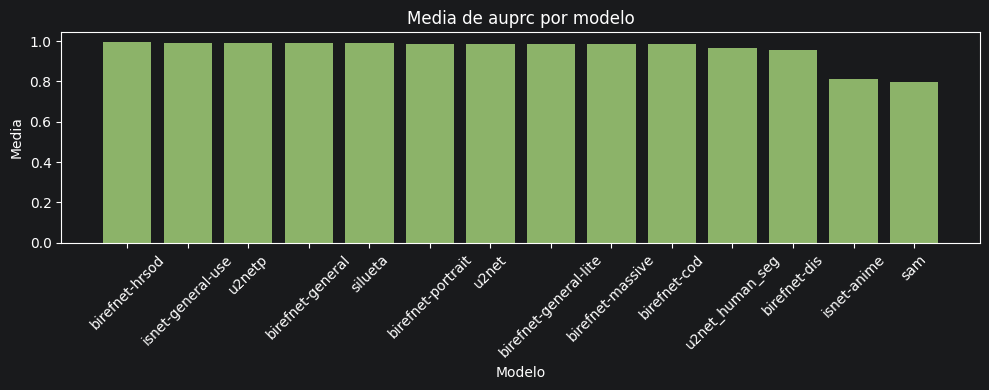

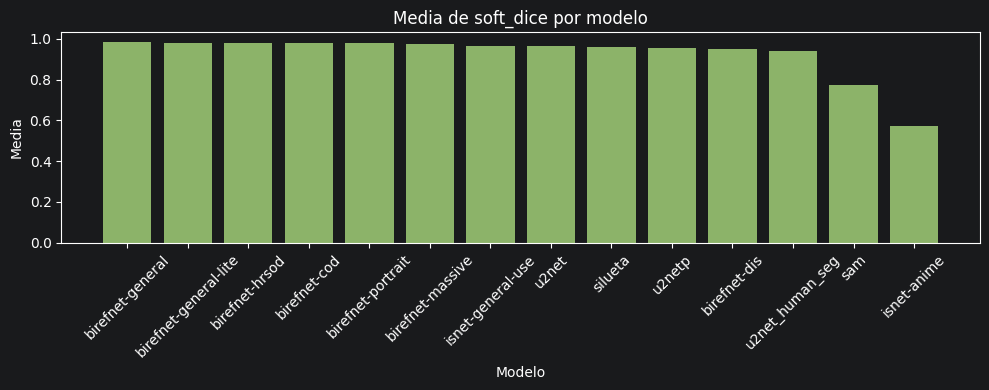

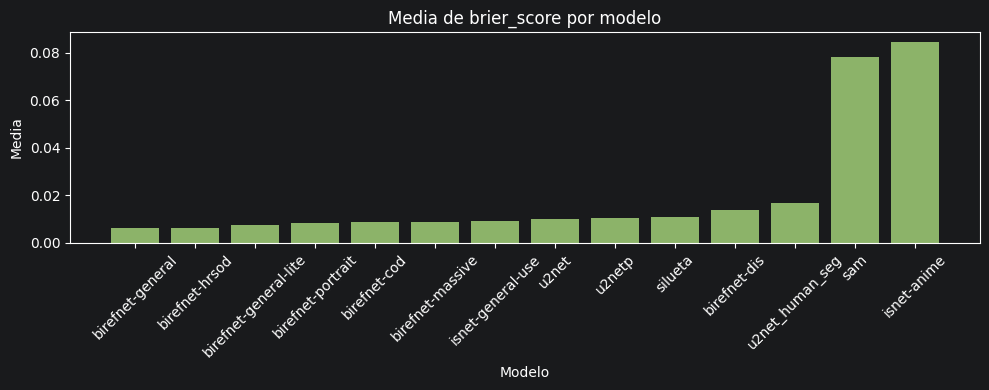

In [3]:
texto_visao_modelo = 'A tabela abaixo resume medias e medianas por metrica, e os graficos ajudam a comparar os modelos de forma agregada antes de olhar significancia e dificuldade.'
figures_visao_modelo = []

display(df_resumo_modelo.pivot(index='nome_modelo', columns='metric_name', values='mean').sort_index())
display(df_resumo_modelo.pivot(index='nome_modelo', columns='metric_name', values='median').sort_index())

for metric_name in metric_names:
    fig, _ = plot_metric_bars_by_model(df_resumo_modelo, metric_name)
    figures_visao_modelo.append(fig)
    plt.show()


## Intervalos de confianca por modelo

Os intervalos de confianca ajudam a evitar conclusoes baseadas apenas na media. Aqui usamos bootstrap para a media de cada metrica por modelo.


,nome_modelo,metric_name,statistic_name,count,estimate,ci_low,ci_high,confidence_level,n_resamples,higher_is_better
0,"('birefnet-cod',)",auprc,mean,1161,0.985748,0.983829,0.987676,0.95,1000,True
6,"('birefnet-dis',)",auprc,mean,1161,0.954597,0.947729,0.961496,0.95,1000,True
12,"('birefnet-general',)",auprc,mean,1161,0.989522,0.987732,0.991109,0.95,1000,True
18,"('birefnet-general-lite',)",auprc,mean,1161,0.986632,0.984742,0.988413,0.95,1000,True
24,"('birefnet-hrsod',)",auprc,mean,1161,0.994105,0.992823,0.995419,0.95,1000,True
30,"('birefnet-massive',)",auprc,mean,1161,0.986185,0.983731,0.988556,0.95,1000,True
36,"('birefnet-portrait',)",auprc,mean,1161,0.987144,0.985213,0.989062,0.95,1000,True
42,"('isnet-anime',)",auprc,mean,1161,0.813369,0.798642,0.828151,0.95,1000,True
48,"('isnet-general-use',)",auprc,mean,1161,0.991877,0.990713,0.992950,0.95,1000,True
54,"('sam',)",auprc,mean,1161,0.799289,0.780167,0.816984,0.95,1000,True


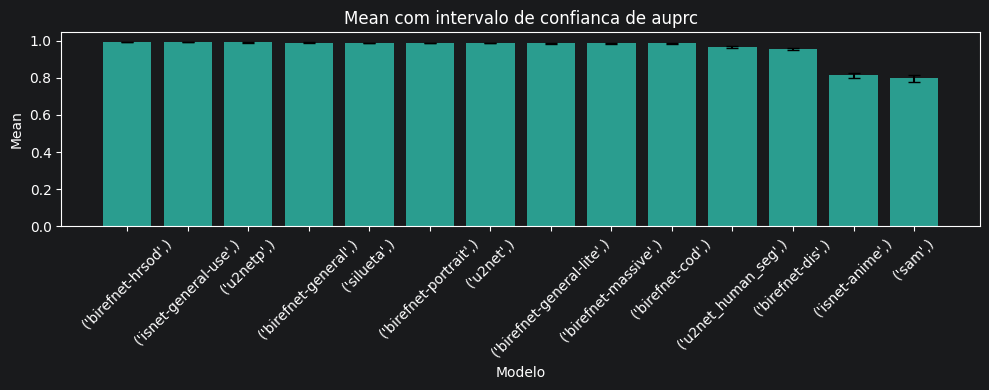

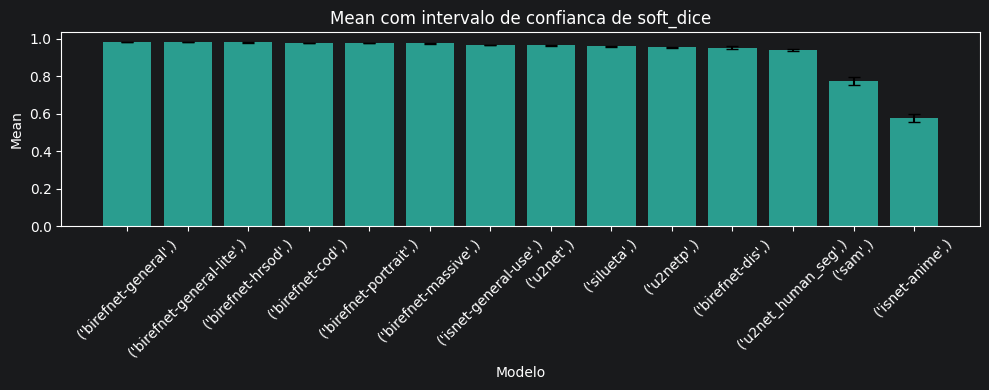

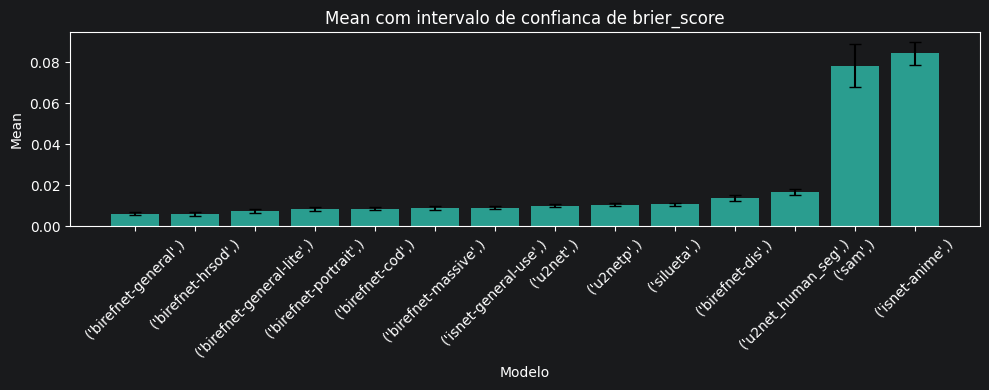

In [4]:
texto_intervalos = 'Os intervalos de confianca ajudam a evitar conclusoes baseadas apenas na media. Aqui usamos bootstrap para a media de cada metrica por modelo.'
figures_intervalos = []

display(df_intervalo_confianca.sort_values(['metric_name', 'statistic_name', 'nome_modelo']).head(18))

for metric_name in metric_names:
    fig, _ = plot_metric_bars_with_ci_by_model(df_resumo_modelo, df_intervalo_confianca, metric_name)
    figures_intervalos.append(fig)
    plt.show()


## Estabilidade por execucao

Aqui avaliamos se o comportamento do modelo se mantem estavel entre as execucoes, tanto na media por execucao quanto em medidas de variacao como coeficiente de variacao e amplitude.


,nome_modelo,metric_name,count_execucoes,mean_execucoes,std_execucoes,cv_execucoes,amplitude_execucoes,melhor_execucao,pior_execucao,higher_is_better
0,birefnet-cod,auprc,3,0.985748,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
3,birefnet-dis,auprc,3,0.954597,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
9,birefnet-general-lite,auprc,3,0.986632,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
12,birefnet-hrsod,auprc,3,0.994105,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
15,birefnet-massive,auprc,3,0.986185,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
18,birefnet-portrait,auprc,3,0.987144,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
27,sam,auprc,3,0.799289,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
6,birefnet-general,auprc,3,0.989522,1.359740e-16,1.374138e-16,0.000000e+00,1,3,True
39,u2netp,auprc,3,0.991592,2.487839e-08,2.508934e-08,4.309063e-08,1,2,True
24,isnet-general-use,auprc,3,0.991877,8.305121e-08,8.373140e-08,1.438489e-07,2,3,True


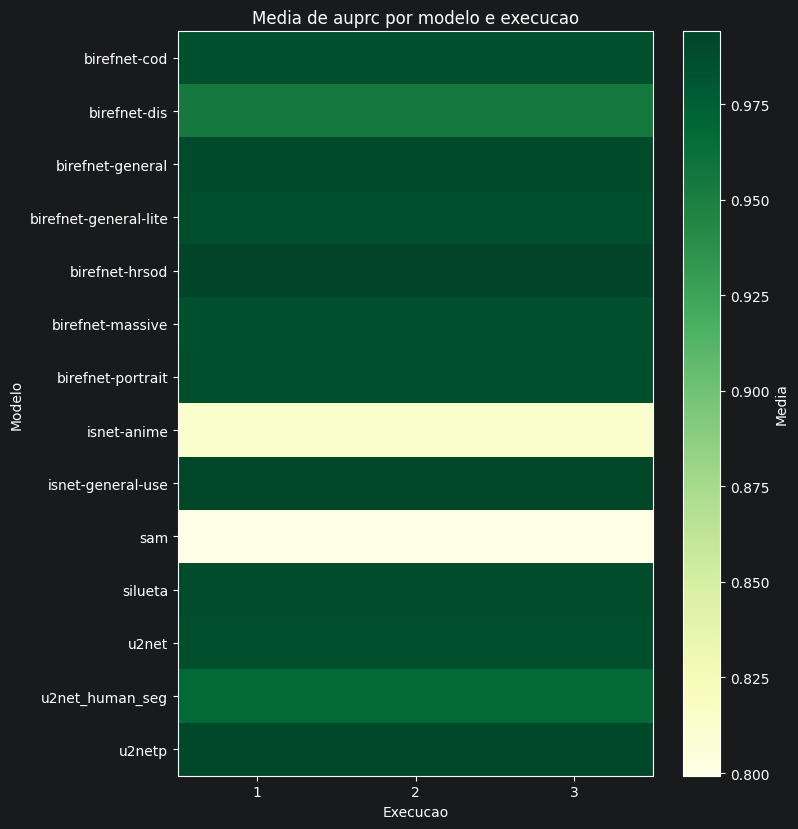

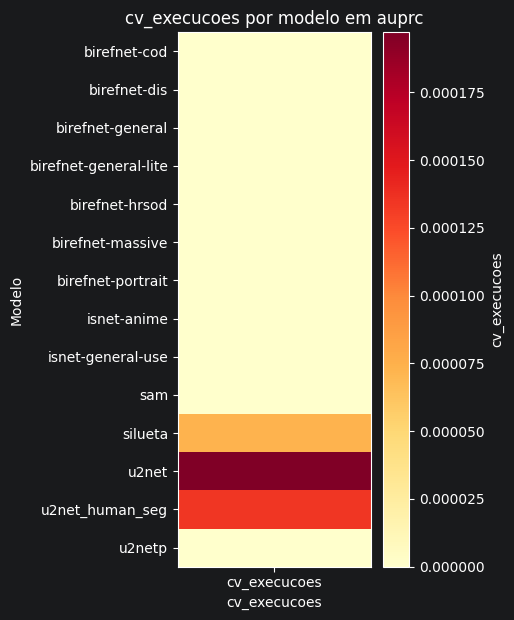

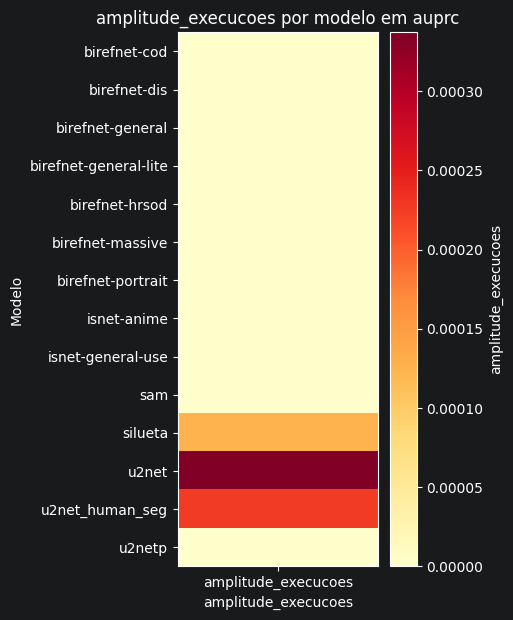

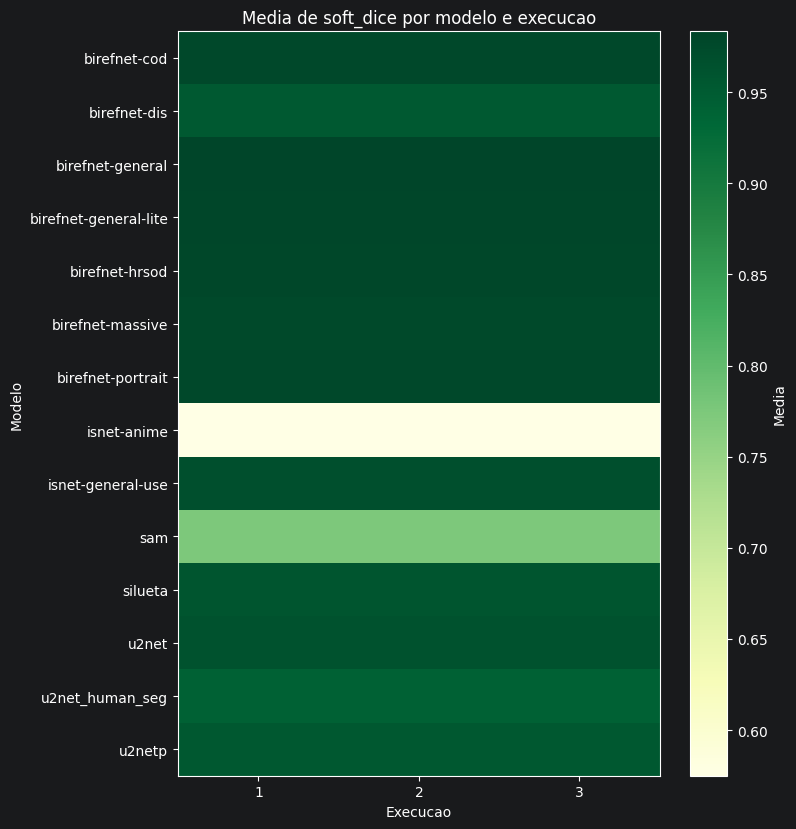

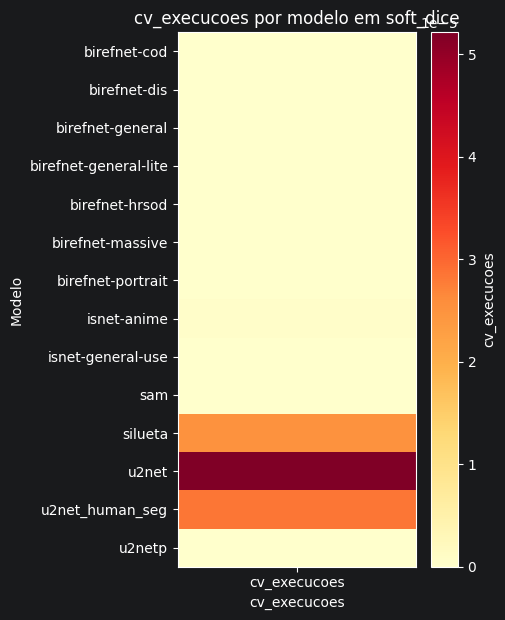

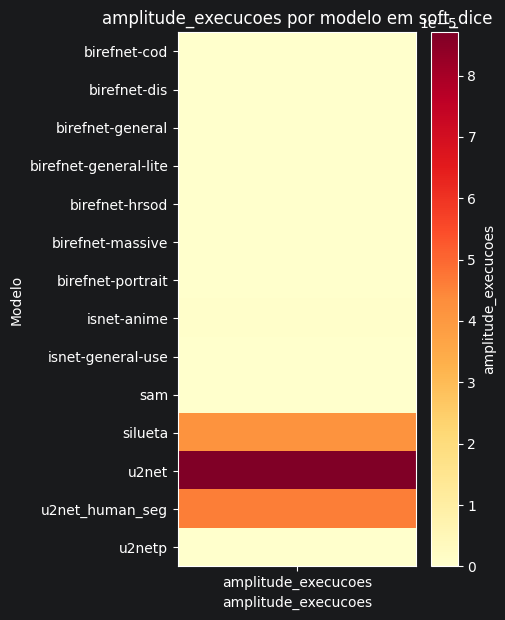

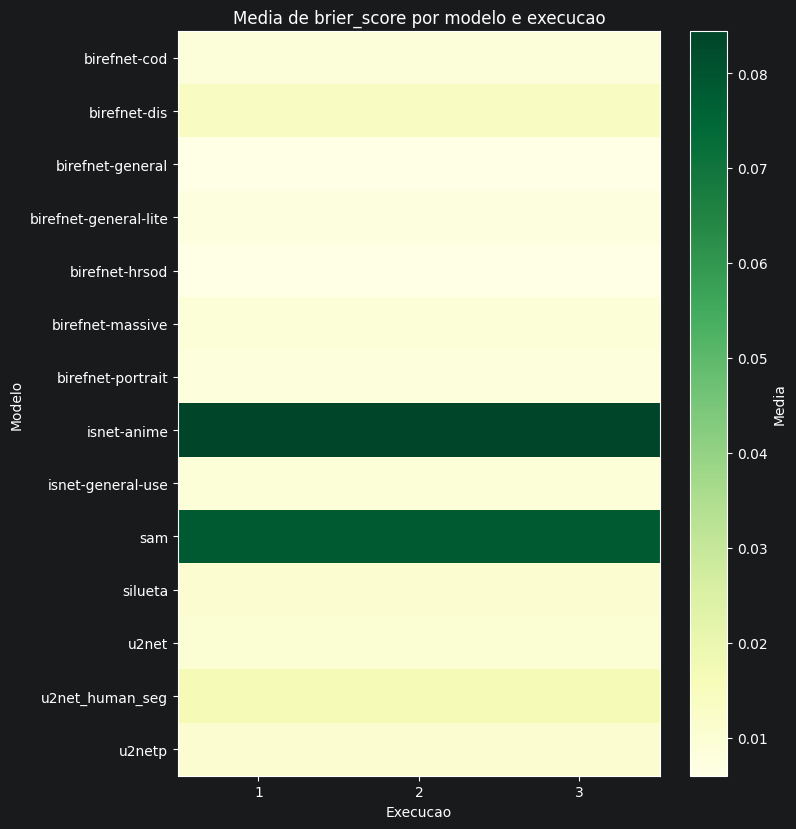

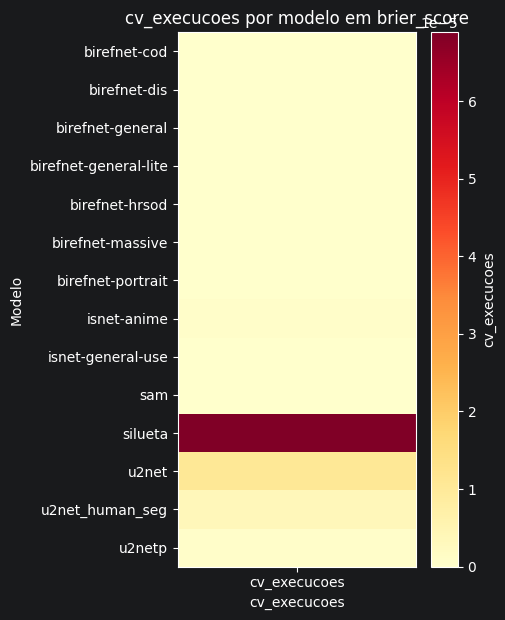

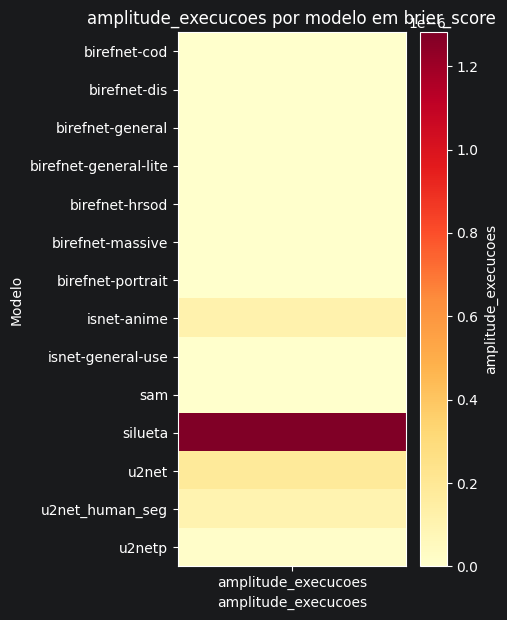

In [5]:
texto_estabilidade_execucao = 'Aqui avaliamos se o comportamento do modelo se mantem estavel entre as execucoes, tanto na media por execucao quanto em medidas de variacao como coeficiente de variacao e amplitude.'
figures_estabilidade_execucao = []

display(df_estabilidade.sort_values(['metric_name', 'cv_execucoes', 'amplitude_execucoes']))

for metric_name in metric_names:
    fig, _ = plot_metric_by_execution_heatmap(df_resumo_execucao, metric_name)
    figures_estabilidade_execucao.append(fig)
    plt.show()

    fig, _ = plot_stability_heatmap(df_estabilidade, metric_name, value_column='cv_execucoes')
    figures_estabilidade_execucao.append(fig)
    plt.show()

    fig, _ = plot_stability_heatmap(df_estabilidade, metric_name, value_column='amplitude_execucoes')
    figures_estabilidade_execucao.append(fig)
    plt.show()


## Comparacao estatistica entre modelos

Quando ha mais de um modelo no banco, este bloco mostra a significancia ajustada das comparacoes par a par entre modelos. Se o ambiente atual tiver apenas um modelo, o bloco fica vazio por definicao.


,metric_name,comparison_scope,test_name,group_a,group_b,n_group_a,n_group_b,statistic,p_value,p_value_adjusted,effect_size,effect_size_label,mean_group_a,mean_group_b,median_group_a,median_group_b,favored_group
0,auprc,global,kruskal_wallis,all_models,,16254,14,5310.930704,0.0,0.0,NaN,NaN,0.958796,0.958796,0.995492,0.995492,NaN
2,auprc,pairwise,dunn_holm,birefnet-cod,birefnet-general,1161,1161,-9.872386,0.0,0.0,-0.348023,medium,0.985748,0.989522,0.994248,0.996545,birefnet-general
4,auprc,pairwise,dunn_holm,birefnet-cod,birefnet-hrsod,1161,1161,-30.399628,0.0,0.0,-0.813152,large,0.985748,0.994105,0.994248,0.998958,birefnet-hrsod
5,auprc,pairwise,dunn_holm,birefnet-cod,birefnet-massive,1161,1161,-14.637474,0.0,0.0,-0.452597,medium,0.985748,0.986185,0.994248,0.997531,birefnet-massive
6,auprc,pairwise,dunn_holm,birefnet-cod,birefnet-portrait,1161,1161,-10.383657,0.0,0.0,-0.326269,small,0.985748,0.987144,0.994248,0.996393,birefnet-portrait
7,auprc,pairwise,dunn_holm,birefnet-cod,isnet-anime,1161,1161,11.158852,0.0,0.0,0.361109,medium,0.985748,0.813369,0.994248,0.945586,birefnet-cod
8,auprc,pairwise,dunn_holm,birefnet-cod,isnet-general-use,1161,1161,-19.353939,0.0,0.0,-0.483204,large,0.985748,0.991877,0.994248,0.998212,isnet-general-use
9,auprc,pairwise,dunn_holm,birefnet-cod,sam,1161,1161,25.747358,0.0,0.0,0.888762,large,0.985748,0.799289,0.994248,0.966460,birefnet-cod
10,auprc,pairwise,dunn_holm,birefnet-cod,silueta,1161,1161,-9.126987,0.0,0.0,-0.236081,small,0.985748,0.988417,0.994248,0.996170,silueta
13,auprc,pairwise,dunn_holm,birefnet-cod,u2netp,1161,1161,-18.086234,0.0,0.0,-0.530544,large,0.985748,0.991592,0.994248,0.997722,u2netp


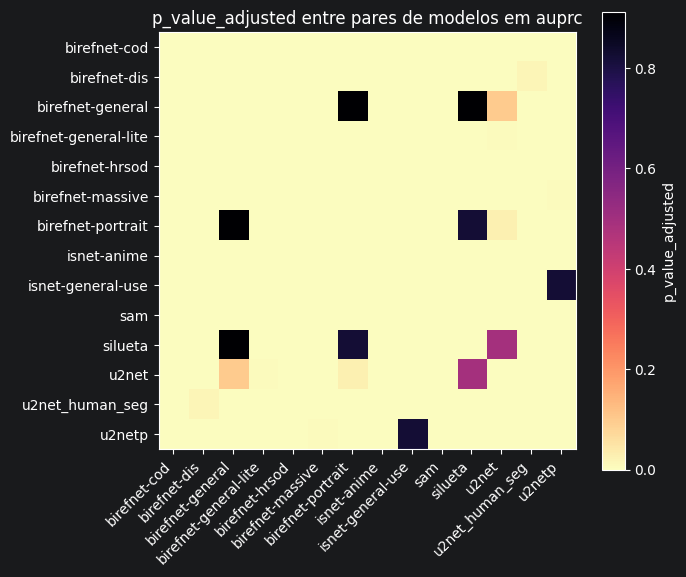

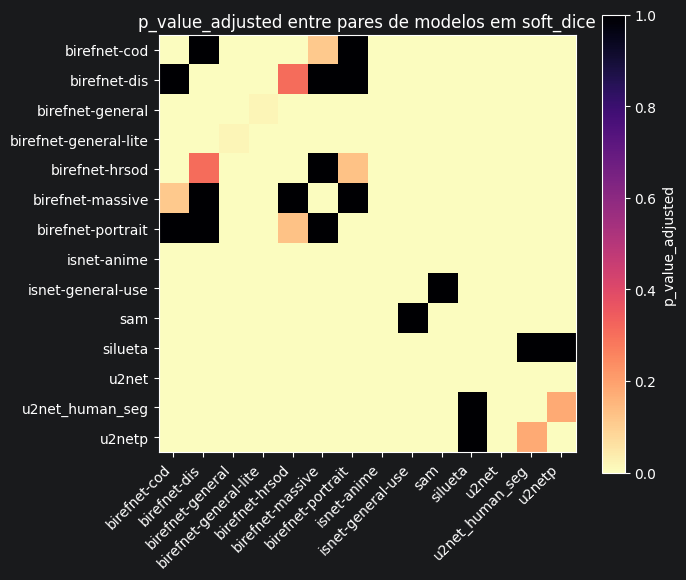

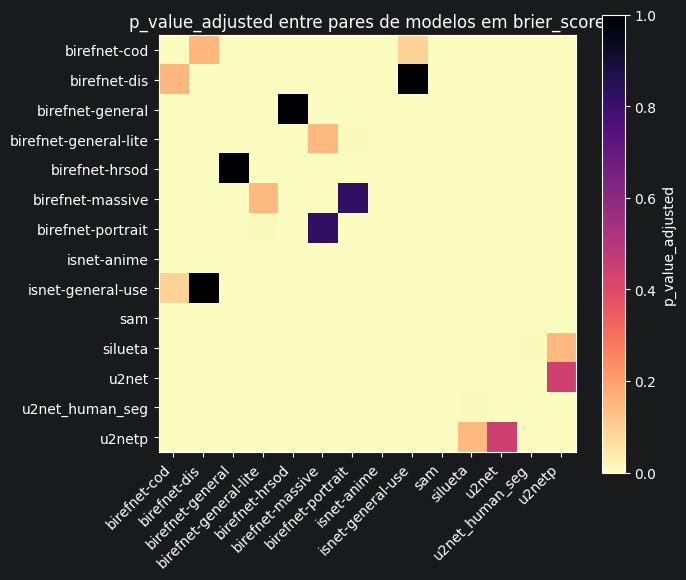

In [6]:
texto_testes_modelo = 'Quando ha mais de um modelo no banco, este bloco mostra a significancia ajustada das comparacoes par a par entre modelos. Se o ambiente atual tiver apenas um modelo, o bloco fica vazio por definicao.'
figures_testes_modelo = []

if df_testes_modelo.empty:
    print('Nao ha comparacoes entre modelos disponiveis neste banco.')
else:
    display(df_testes_modelo.sort_values(['metric_name', 'comparison_scope', 'p_value_adjusted']).head(30))
    for metric_name in metric_names:
        df_pairwise_metric = df_testes_modelo.loc[(df_testes_modelo['metric_name'] == metric_name) & (df_testes_modelo['comparison_scope'] == 'pairwise')]
        if df_pairwise_metric.empty:
            continue
        fig, _ = plot_pairwise_pvalue_heatmap(df_testes_modelo, metric_name)
        figures_testes_modelo.append(fig)
        plt.show()


## Impacto das tags

As tags entram como eixo explicativo do que degrada a segmentacao. Aqui mostramos tanto a comparacao agregada por tag quanto o tamanho de efeito estimado para cada dificuldade.


,metric_name,tag_name,comparison_scope,nome_modelo,test_name,n_group_a,n_group_b,statistic,p_value,p_value_adjusted,effect_size,effect_size_label,mean_com_tag,mean_sem_tag,median_com_tag,median_sem_tag,delta_mean,delta_median
0,auprc,tag_angulo_extremo,global,__global__,mann_whitney_u,1932,14322,13357719.0,1.368054e-02,1.368054e-02,-0.034502,negligible,0.966727,0.957726,0.995345,0.995511,0.009001,-0.000166
1,auprc,tag_angulo_extremo,por_modelo,birefnet-cod,mann_whitney_u,138,1023,92988.0,1.373481e-09,1.922873e-08,0.317353,small,0.983709,0.986023,0.996021,0.993975,-0.002314,0.002046
12,auprc,tag_angulo_extremo,por_modelo,u2net,mann_whitney_u,138,1023,52336.0,7.969399e-07,1.036022e-05,-0.258560,small,0.979895,0.987958,0.991429,0.996053,-0.008064,-0.004624
9,auprc,tag_angulo_extremo,por_modelo,isnet-general-use,mann_whitney_u,138,1023,54279.0,1.030829e-05,1.236995e-04,-0.231034,small,0.988461,0.992337,0.995830,0.998432,-0.003876,-0.002602
6,auprc,tag_angulo_extremo,por_modelo,birefnet-massive,mann_whitney_u,138,1023,54423.0,1.233025e-05,1.276379e-04,-0.228994,small,0.959719,0.989755,0.996382,0.997611,-0.030036,-0.001228
11,auprc,tag_angulo_extremo,por_modelo,silueta,mann_whitney_u,138,1023,54374.0,1.160344e-05,1.276379e-04,-0.229688,small,0.981317,0.989374,0.993073,0.996514,-0.008058,-0.003442
7,auprc,tag_angulo_extremo,por_modelo,birefnet-portrait,mann_whitney_u,138,1023,83880.0,3.241930e-04,2.917737e-03,0.188321,small,0.983434,0.987645,0.997204,0.996106,-0.004211,0.001097
3,auprc,tag_angulo_extremo,por_modelo,birefnet-general,mann_whitney_u,138,1023,81909.0,2.198103e-03,1.758482e-02,0.160398,small,0.989974,0.989461,0.996891,0.996486,0.000513,0.000405
5,auprc,tag_angulo_extremo,por_modelo,birefnet-hrsod,mann_whitney_u,138,1023,79893.0,1.184212e-02,8.289482e-02,0.131837,negligible,0.994301,0.994079,0.999209,0.998942,0.000222,0.000267
10,auprc,tag_angulo_extremo,por_modelo,sam,mann_whitney_u,138,1023,77184.0,7.440351e-02,4.464210e-01,0.093459,negligible,0.875235,0.789044,0.970294,0.965601,0.086191,0.004693


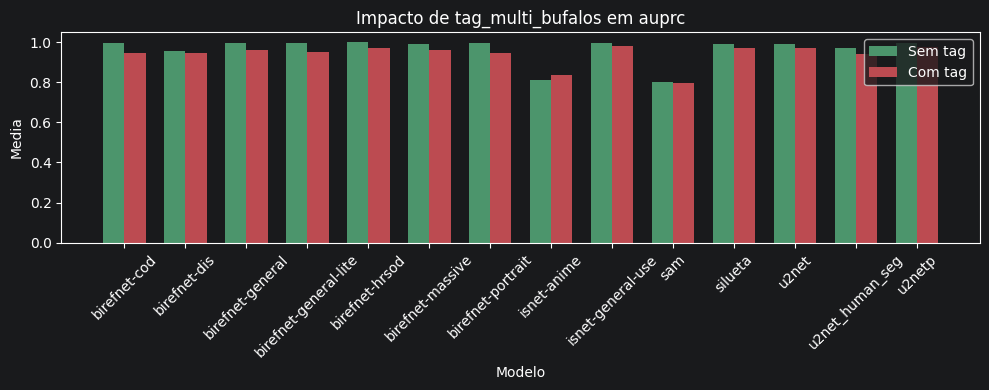

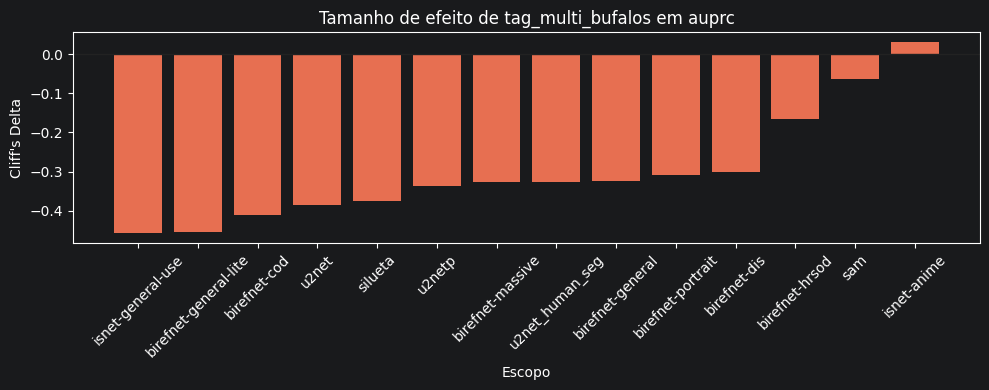

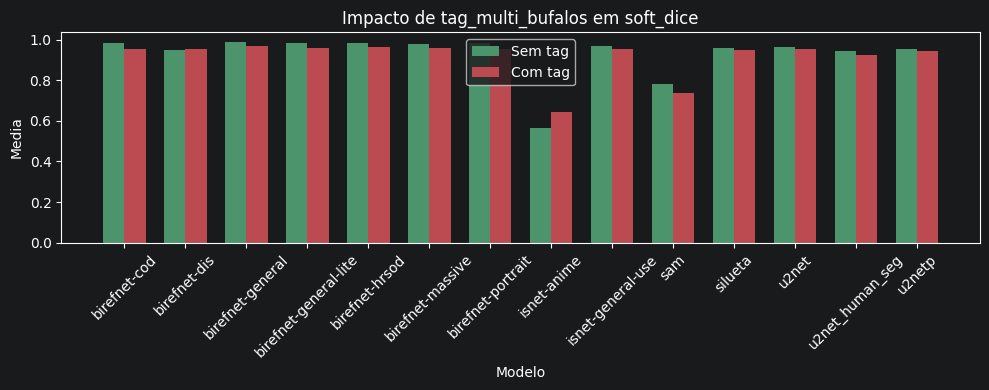

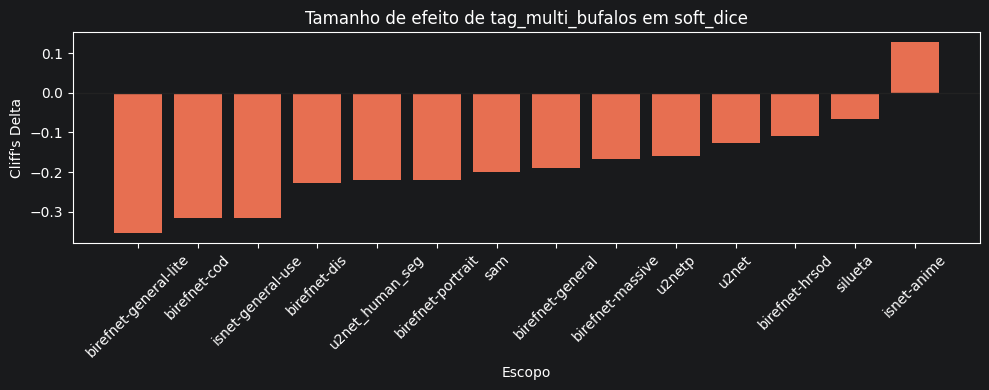

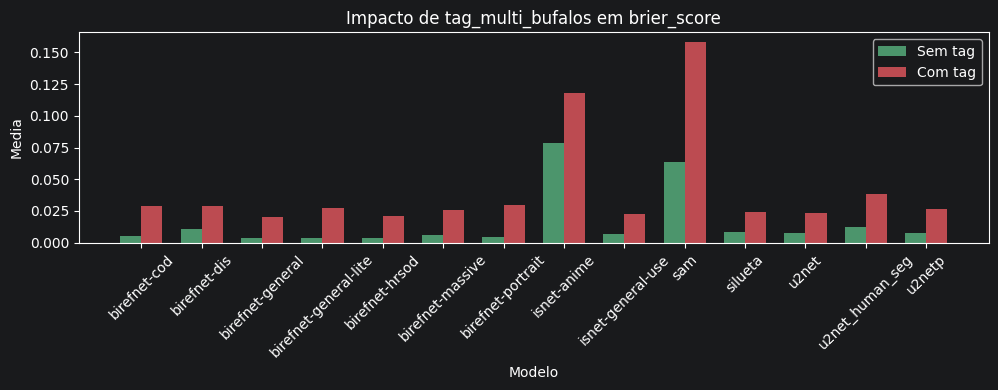

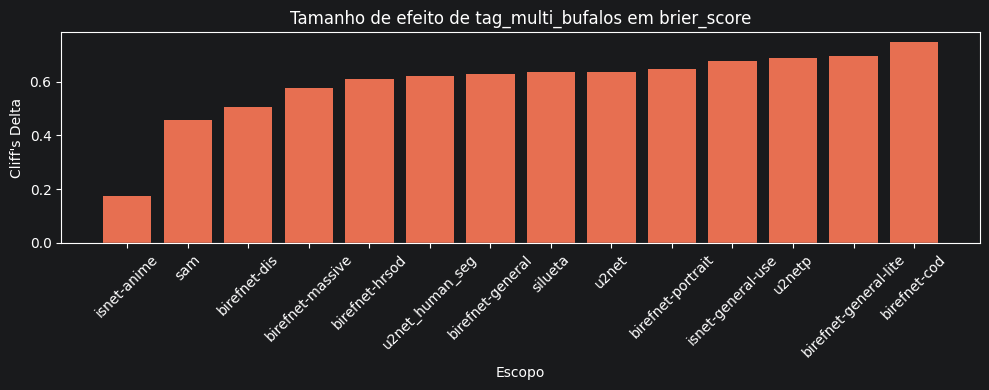

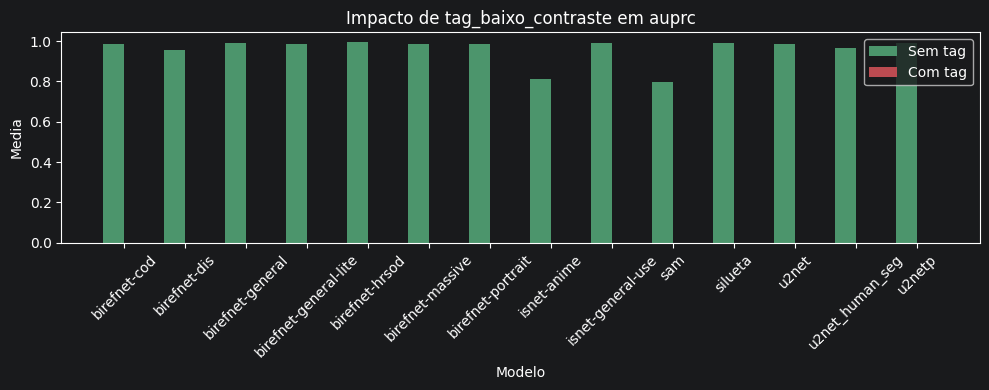

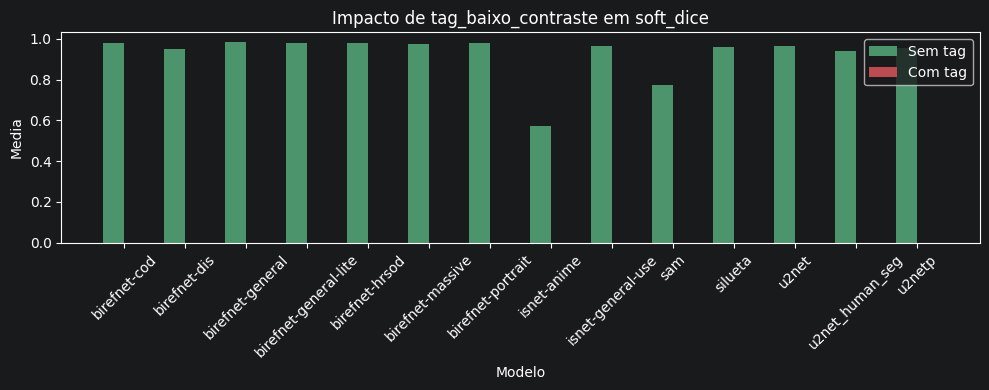

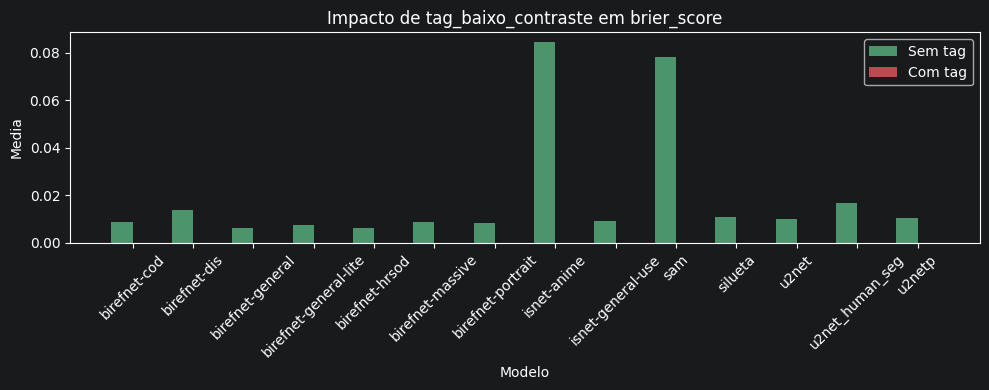

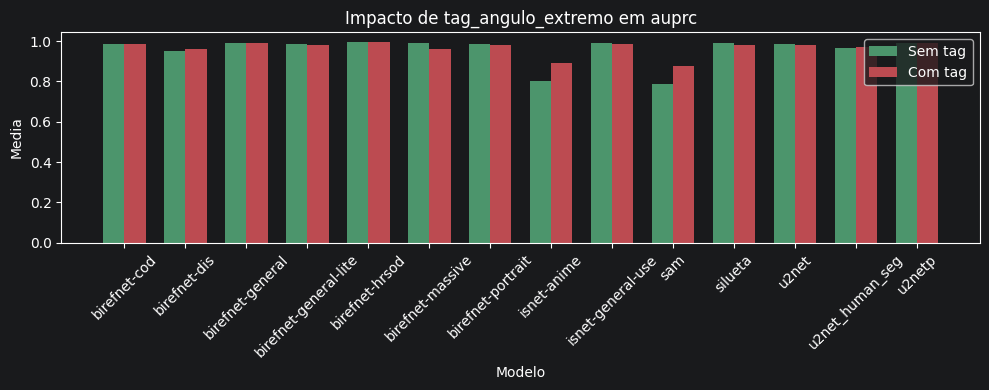

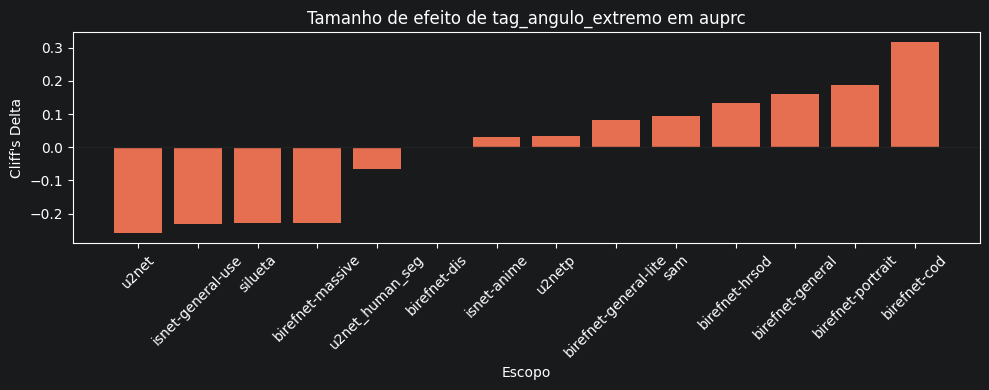

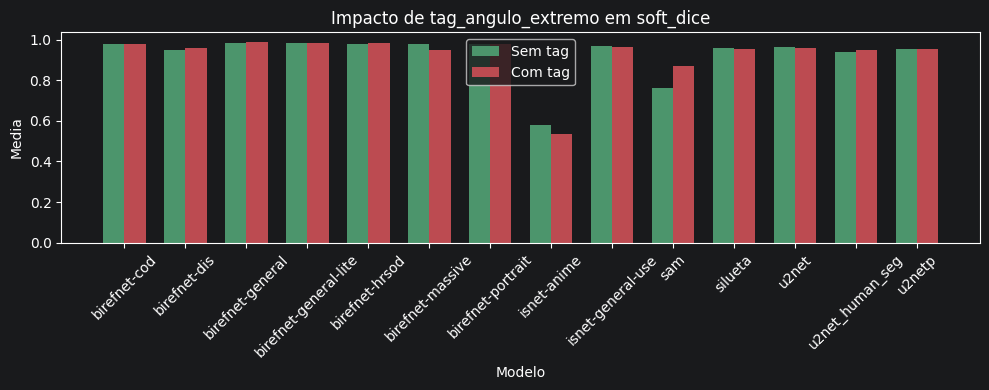

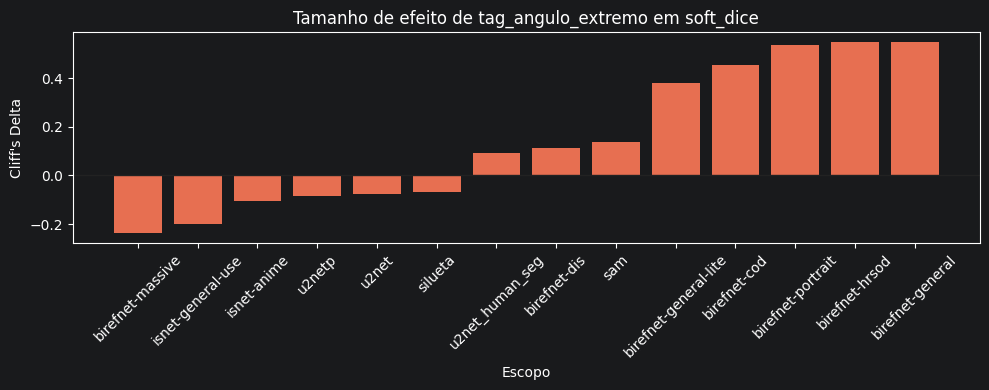

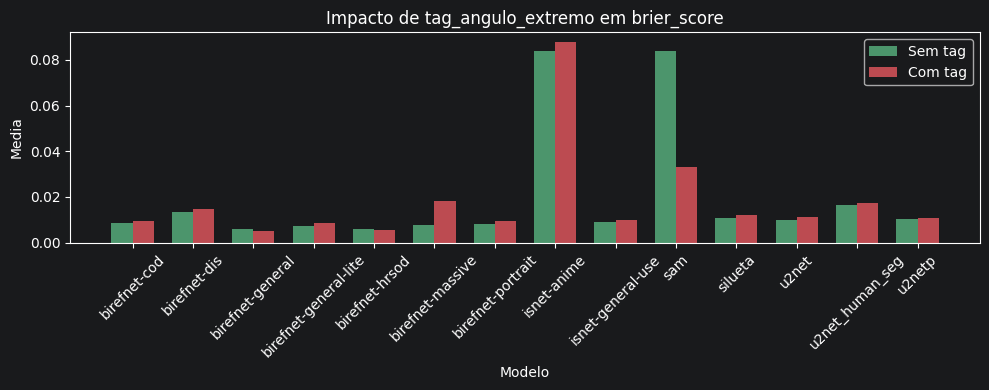

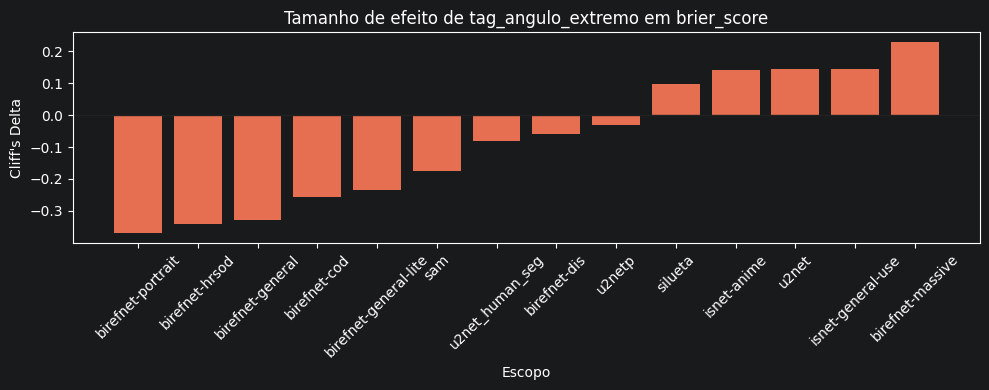

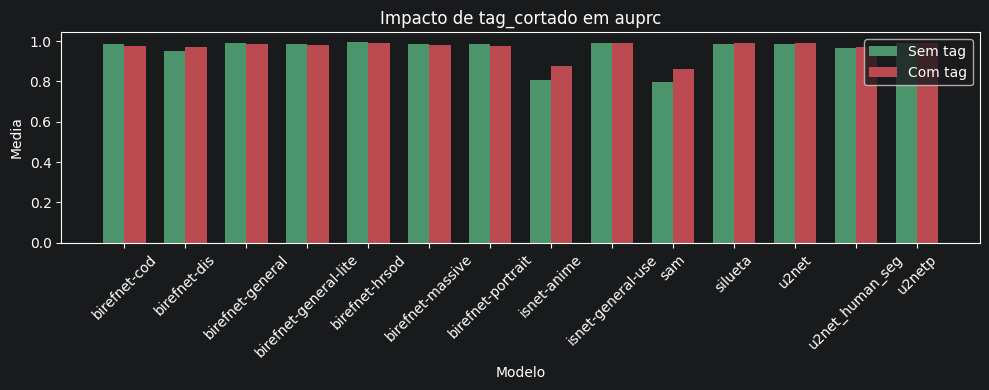

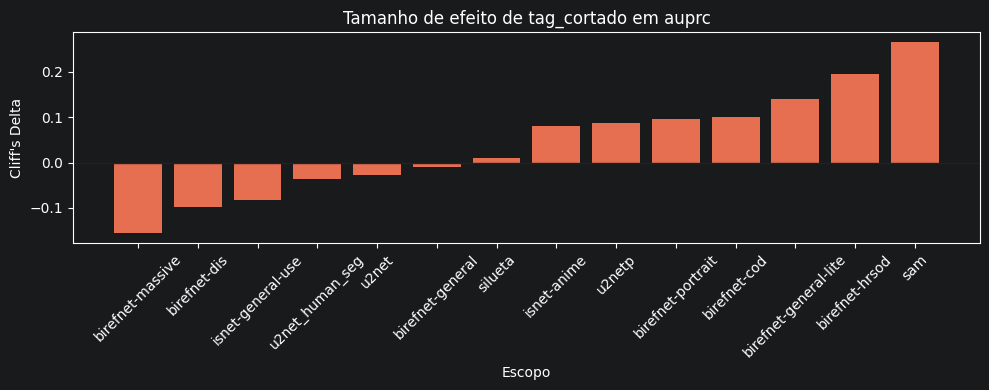

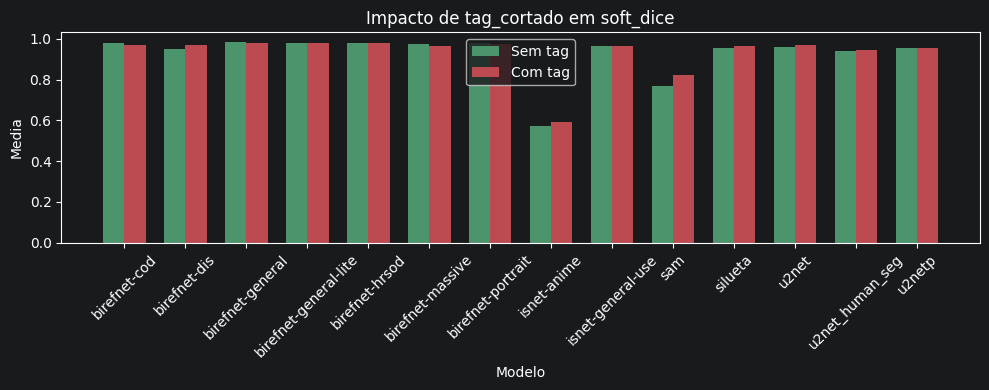

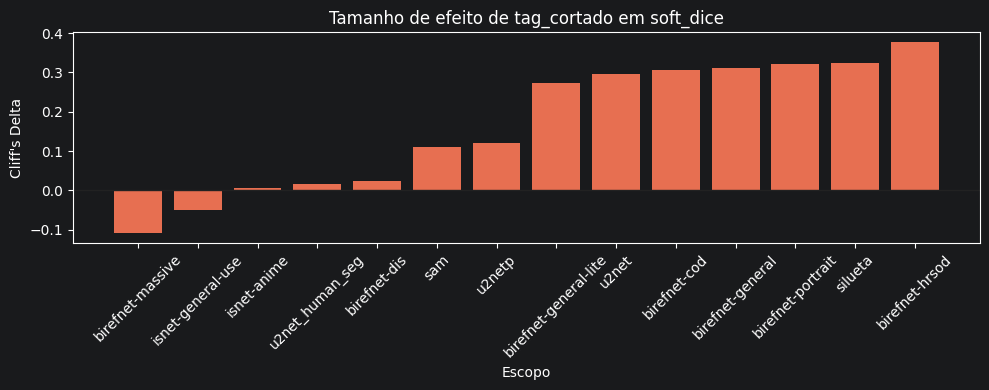

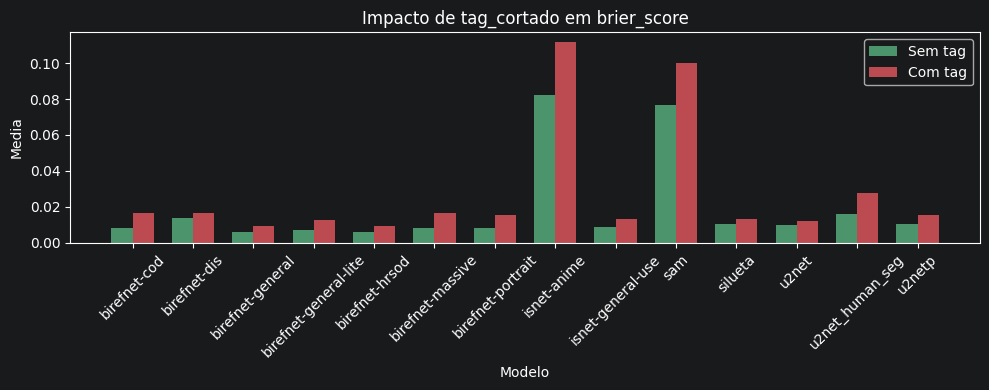

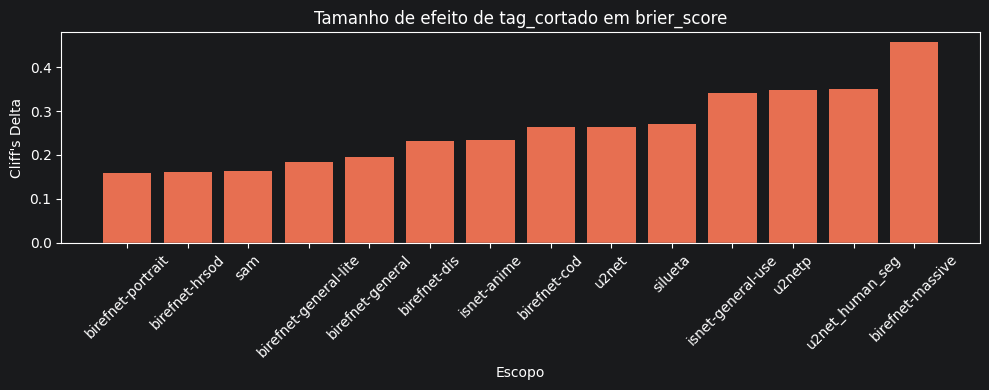

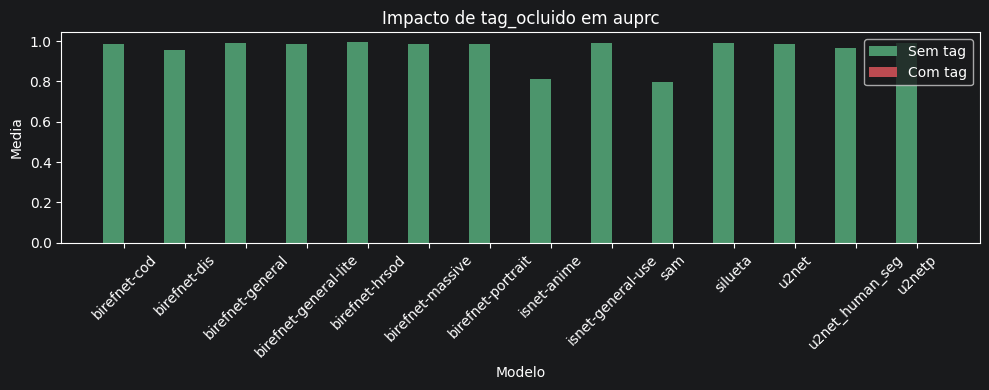

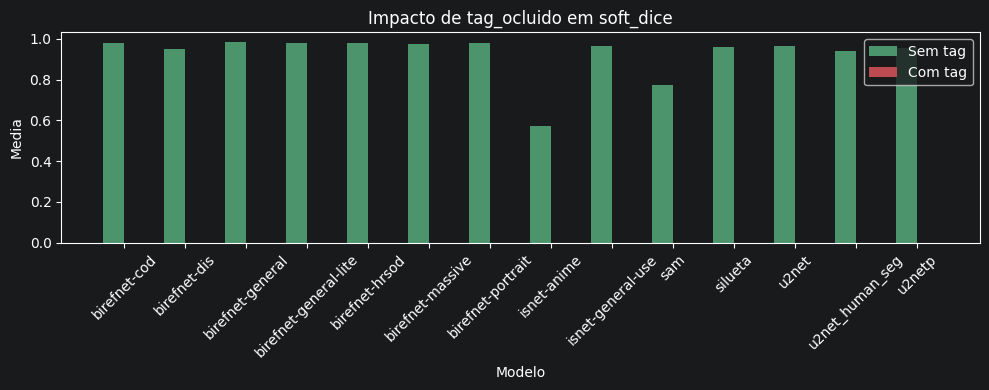

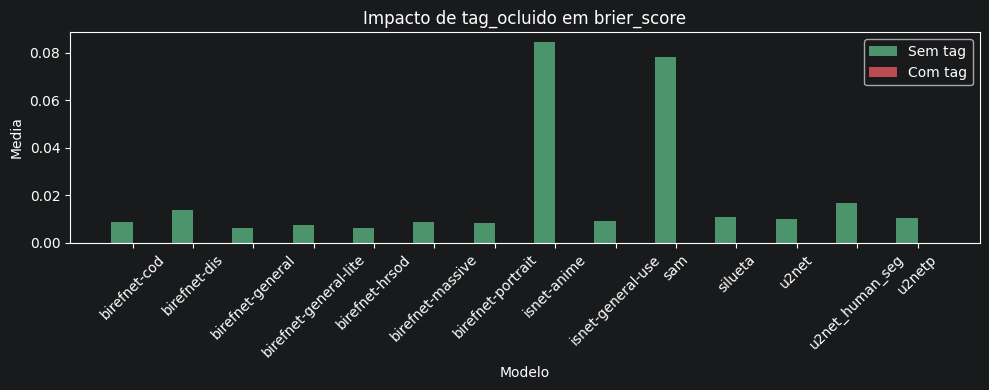

In [7]:
texto_impacto_tags = 'As tags entram como eixo explicativo do que degrada a segmentacao. Aqui mostramos tanto a comparacao agregada por tag quanto o tamanho de efeito estimado para cada dificuldade.'
figures_impacto_tags = []

display(df_testes_tag.sort_values(['metric_name', 'tag_name', 'comparison_scope', 'p_value_adjusted']).head(30))

for tag_name in tags_prioritarias:
    for metric_name in metric_names:
        fig, _ = plot_metric_tag_comparison(df_resumo_tag, metric_name, tag_name)
        figures_impacto_tags.append(fig)
        plt.show()

        df_effect_metric = df_testes_tag.loc[(df_testes_tag['metric_name'] == metric_name) & (df_testes_tag['tag_name'] == tag_name) & (df_testes_tag['comparison_scope'] == 'por_modelo')]
        if df_effect_metric.empty:
            continue
        fig, _ = plot_tag_effect_bars(df_testes_tag, metric_name, tag_name, comparison_scope='por_modelo')
        figures_impacto_tags.append(fig)
        plt.show()


## Interacao modelo x dificuldade

Este bloco destaca quais modelos sofrem mais com cada dificuldade, usando o delta ajustado pela direcao desejada da metrica.


,nome_modelo,tag_name,metric_name,count_com_tag,count_sem_tag,mean_com_tag,mean_sem_tag,median_com_tag,median_sem_tag,delta_mean,delta_median,relative_delta_mean,adjusted_delta_mean,adjusted_delta_median,impact_direction,higher_is_better
60,birefnet-massive,tag_angulo_extremo,auprc,138,1023,0.959719,0.989755,0.996382,0.997611,-0.030036,-0.001228,-0.030347,-0.030036,-0.001228,piora,True
132,u2net,tag_angulo_extremo,auprc,138,1023,0.979895,0.987958,0.991429,0.996053,-0.008064,-0.004624,-0.008162,-0.008064,-0.004624,piora,True
120,silueta,tag_angulo_extremo,auprc,138,1023,0.981317,0.989374,0.993073,0.996514,-0.008058,-0.003442,-0.008144,-0.008058,-0.003442,piora,True
72,birefnet-portrait,tag_angulo_extremo,auprc,138,1023,0.983434,0.987645,0.997204,0.996106,-0.004211,0.001097,-0.004264,-0.004211,0.001097,piora,True
96,isnet-general-use,tag_angulo_extremo,auprc,138,1023,0.988461,0.992337,0.995830,0.998432,-0.003876,-0.002602,-0.003906,-0.003876,-0.002602,piora,True
36,birefnet-general-lite,tag_angulo_extremo,auprc,138,1023,0.983425,0.987064,0.995618,0.994783,-0.003639,0.000834,-0.003687,-0.003639,0.000834,piora,True
0,birefnet-cod,tag_angulo_extremo,auprc,138,1023,0.983709,0.986023,0.996021,0.993975,-0.002314,0.002046,-0.002347,-0.002314,0.002046,piora,True
48,birefnet-hrsod,tag_angulo_extremo,auprc,138,1023,0.994301,0.994079,0.999209,0.998942,0.000222,0.000267,0.000223,0.000222,0.000267,melhora,True
24,birefnet-general,tag_angulo_extremo,auprc,138,1023,0.989974,0.989461,0.996891,0.996486,0.000513,0.000405,0.000519,0.000513,0.000405,melhora,True
156,u2netp,tag_angulo_extremo,auprc,138,1023,0.993405,0.991348,0.998032,0.997700,0.002057,0.000333,0.002075,0.002057,0.000333,melhora,True


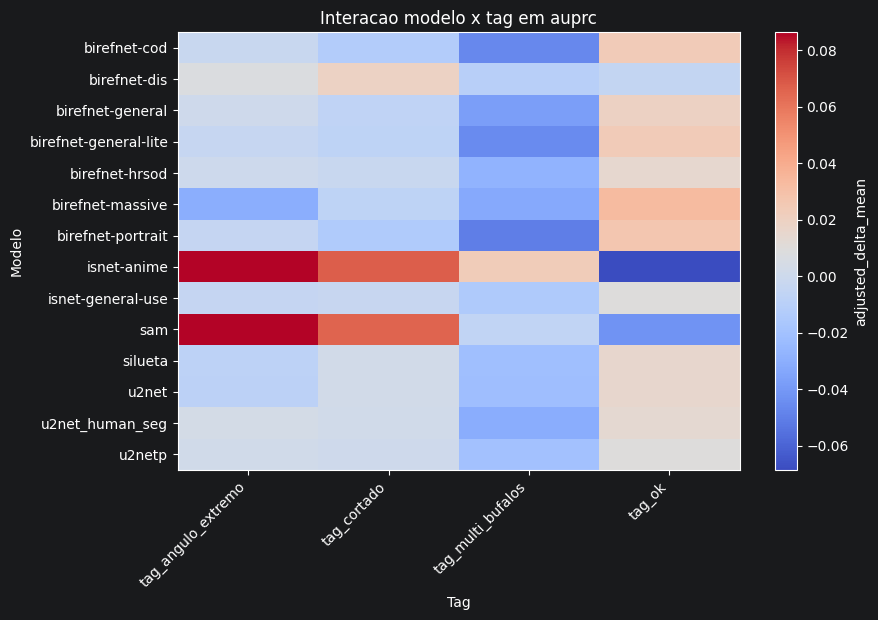

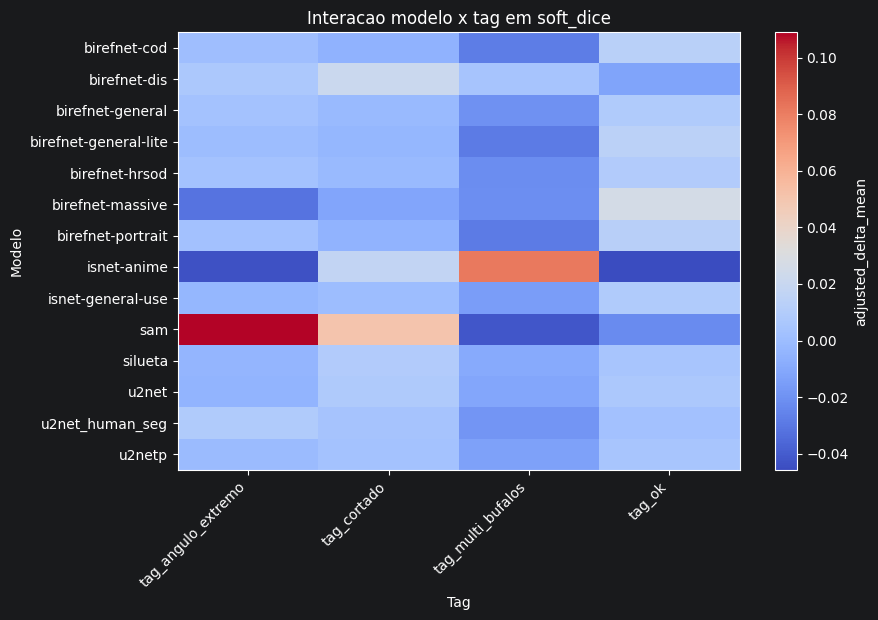

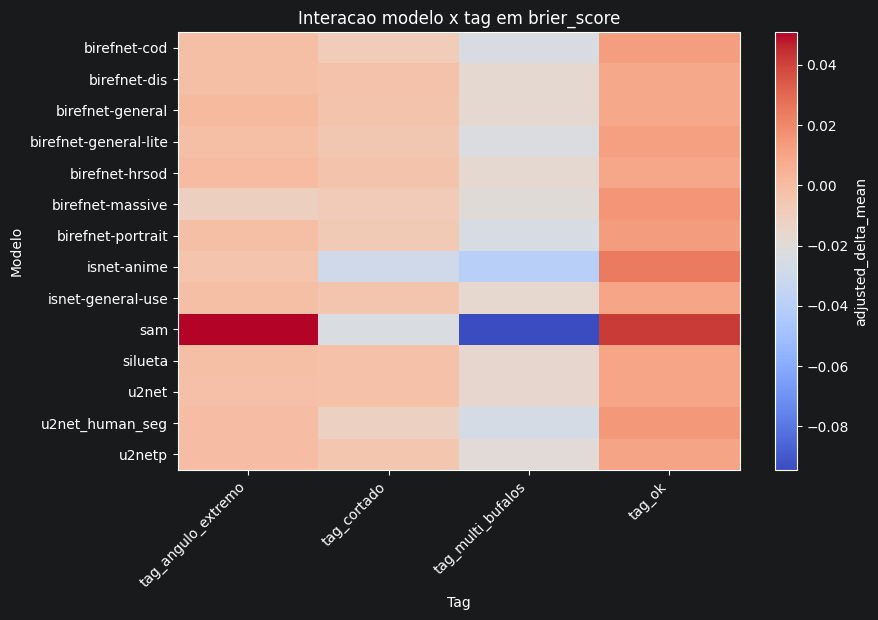

In [8]:
texto_interacoes = 'Este bloco destaca quais modelos sofrem mais com cada dificuldade, usando o delta ajustado pela direcao desejada da metrica.'
figures_interacoes = []

display(df_interacoes_tag_modelo.sort_values(['metric_name', 'tag_name', 'adjusted_delta_mean']).head(30))

for metric_name in metric_names:
    fig, _ = plot_model_tag_interaction_heatmap(df_interacoes_tag_modelo, metric_name)
    figures_interacoes.append(fig)
    plt.show()


## Distribuicao linha a linha

Os boxplots usam a base completa em memoria para mostrar dispersao e caudas, algo que os resumos persistidos e os testes inferenciais nao capturam sozinhos.


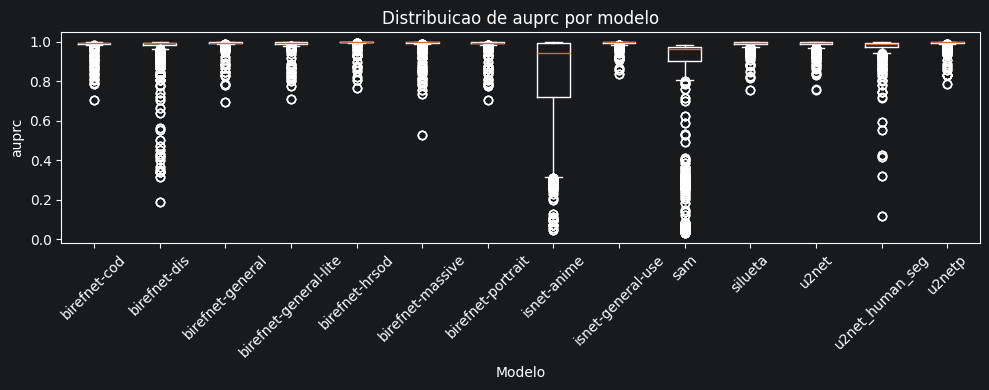

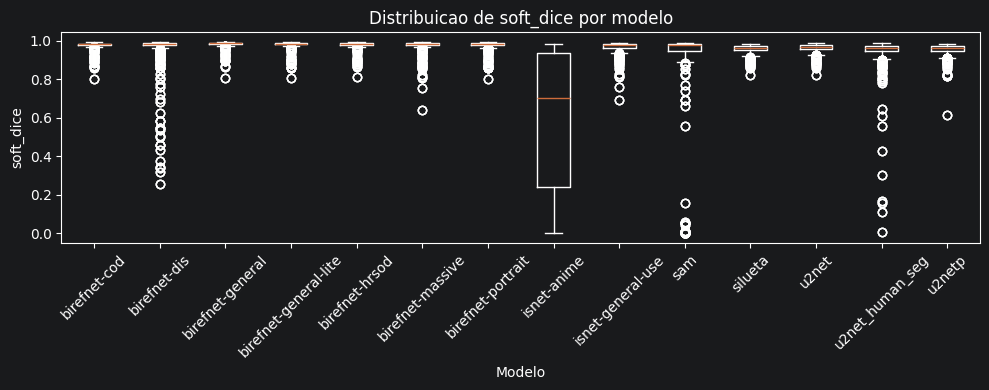

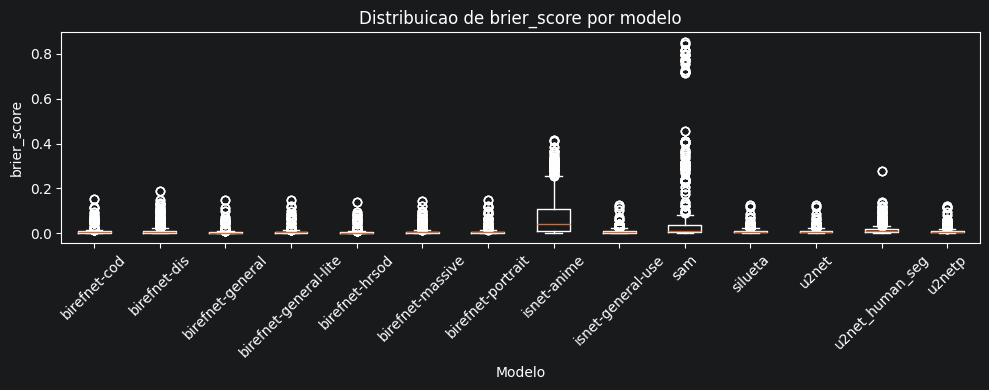

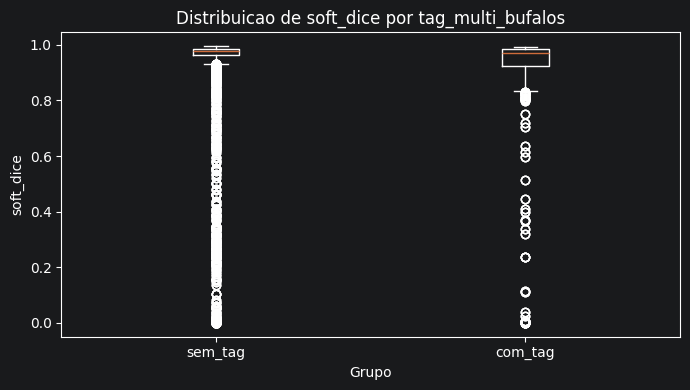

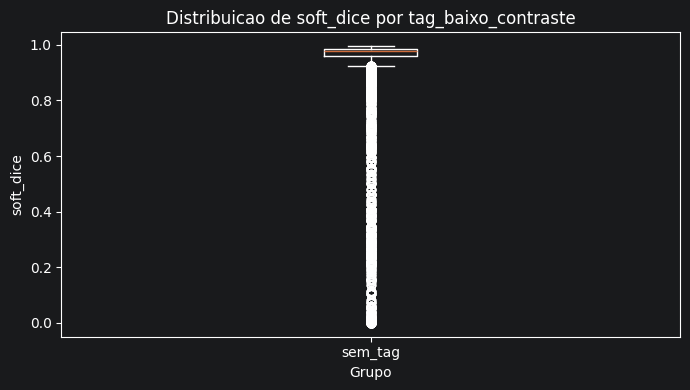

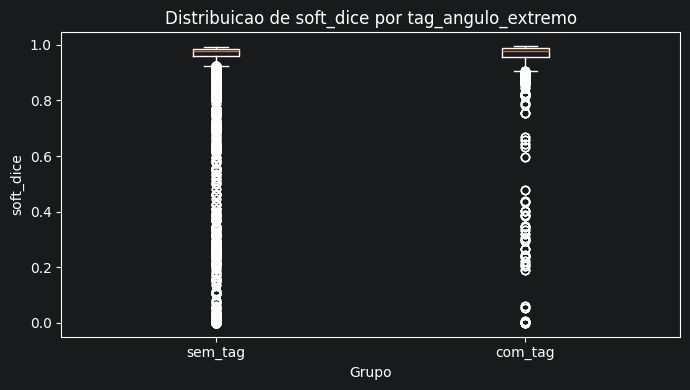

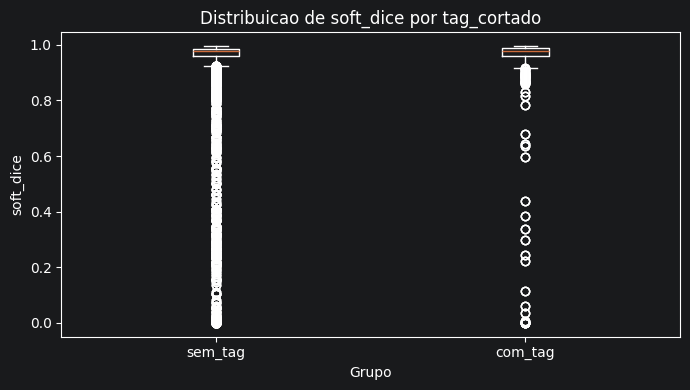

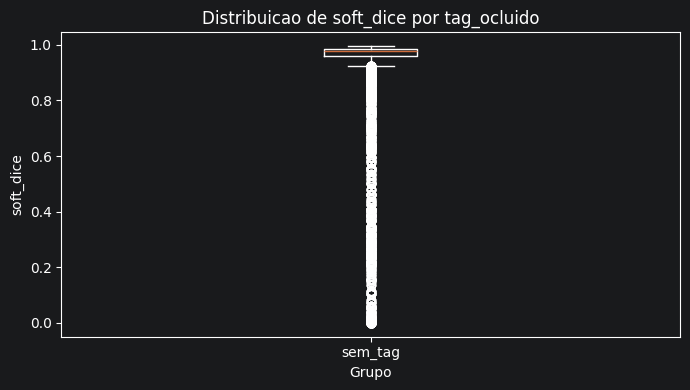

In [9]:
texto_distribuicao = 'Os boxplots usam a base completa em memoria para mostrar dispersao e caudas, algo que os resumos persistidos e os testes inferenciais nao capturam sozinhos.'
figures_distribuicao = []

for metric_name in metric_names:
    fig, _ = plot_metric_distribution_by_model(df_base, metric_name)
    figures_distribuicao.append(fig)
    plt.show()

for tag_name in tags_prioritarias:
    fig, _ = plot_metric_distribution_by_tag(df_base, 'soft_dice', tag_name)
    figures_distribuicao.append(fig)
    plt.show()


## Leitura inicial

Com a combinacao entre medias, intervalos de confianca, estabilidade, significancia entre modelos, impacto das tags e interacoes `modelo x dificuldade`, o notebook 05 passa a refletir melhor a camada estatistica calculada pelo notebook 04.


In [10]:
report_sections = [
    PdfReportSection(
        heading='Carregamento das tabelas analiticas e da base linha a linha',
        body='Os resumos, testes e medidas de estabilidade sao lidos do SQLite. A base linha a linha e reconstruida apenas para os boxplots e leituras de distribuicao.',
    ),
    PdfReportSection(heading='Visao geral por modelo', body=texto_visao_modelo, figures=figures_visao_modelo),
    PdfReportSection(heading='Intervalos de confianca por modelo', body=texto_intervalos, figures=figures_intervalos),
    PdfReportSection(heading='Estabilidade por execucao', body=texto_estabilidade_execucao, figures=figures_estabilidade_execucao),
    PdfReportSection(heading='Comparacao estatistica entre modelos', body=texto_testes_modelo, figures=figures_testes_modelo),
    PdfReportSection(heading='Impacto das tags', body=texto_impacto_tags, figures=figures_impacto_tags),
    PdfReportSection(heading='Interacao modelo x dificuldade', body=texto_interacoes, figures=figures_interacoes),
    PdfReportSection(heading='Distribuicao linha a linha', body=texto_distribuicao, figures=figures_distribuicao),
    PdfReportSection(
        heading='Leitura inicial',
        body='Com a combinacao entre medias, intervalos de confianca, estabilidade, significancia entre modelos, impacto das tags e interacoes modelo x dificuldade, o notebook 05 passa a refletir melhor a camada estatistica calculada pelo notebook 04.',
    ),
]

pdf_path = save_pdf_report(
    output_path=report_output_path,
    sections=report_sections,
    report_title='05 - Visualizacao da Segmentacao Bruta',
)

print(f'Relatorio PDF salvo em: {pdf_path}')


Relatorio PDF salvo em: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/05_visualizacao_segmentacao_bruta.pdf
